In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [15]:
# Load dataset (adjust path if needed)
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (41188, 21)

Columns:
 ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [16]:
# Check data types and missing values
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())


Data types:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Missing values per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed      

In [17]:
# Convert target 'y' to binary (1 = subscribed = customer, 0 = not)
df['converted'] = df['y'].map({'yes': 1, 'no': 0})

# Keep a copy of the original 'y' for reference
df['subscribed'] = df['y']

# Drop the original 'y' (optional)
# df.drop('y', axis=1, inplace=True)

# Create an 'engaged' flag for the middle funnel stage
# Engaged = previous campaign success OR call duration above median
median_duration = df['duration'].median()
df['engaged'] = ((df['poutcome'] == 'success') | (df['duration'] > median_duration)).astype(int)

print("Median call duration (seconds):", median_duration)
print("\nEngaged rate: {:.1f}%".format(df['engaged'].mean() * 100))
print("Conversion rate (lead → customer): {:.1f}%".format(df['converted'].mean() * 100))

Median call duration (seconds): 180.0

Engaged rate: 50.7%
Conversion rate (lead → customer): 11.3%


In [18]:
# Funnel counts
visitors = len(df)
engaged = df['engaged'].sum()
customers = df['converted'].sum()

print(f"Visitors (all contacts): {visitors}")
print(f"Engaged Leads: {engaged}")
print(f"Customers (subscribed): {customers}")

# Conversion rates
visitor_to_engaged = (engaged / visitors) * 100
engaged_to_customer = (customers / engaged) * 100 if engaged > 0 else 0
overall_conversion = (customers / visitors) * 100

print(f"\nVisitor → Engaged Rate: {visitor_to_engaged:.2f}%")
print(f"Engaged → Customer Rate: {engaged_to_customer:.2f}%")
print(f"Overall Visitor → Customer Rate: {overall_conversion:.2f}%")

Visitors (all contacts): 41188
Engaged Leads: 20881
Customers (subscribed): 4640

Visitor → Engaged Rate: 50.70%
Engaged → Customer Rate: 22.22%
Overall Visitor → Customer Rate: 11.27%


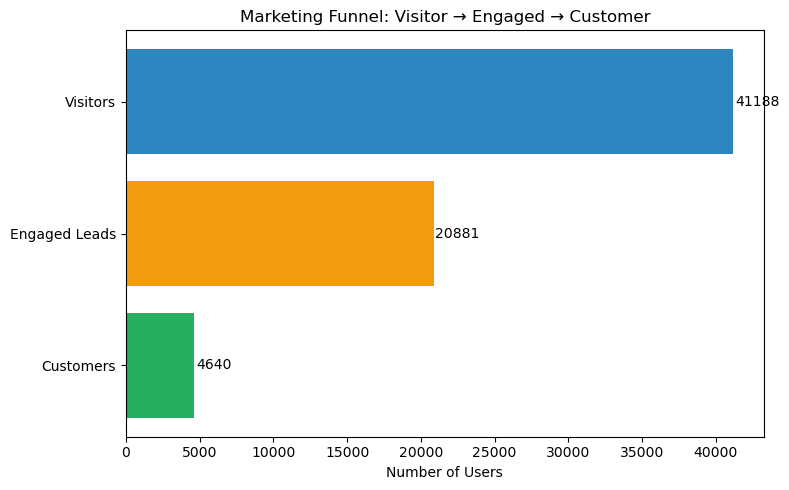

In [19]:
# Funnel chart using matplotlib
stages = ['Visitors', 'Engaged Leads', 'Customers']
counts = [visitors, engaged, customers]

fig, ax = plt.subplots(figsize=(8,5))
y_pos = np.arange(len(stages))
ax.barh(y_pos, counts, color=['#2E86C1', '#F39C12', '#27AE60'])
ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.invert_yaxis()
ax.set_xlabel('Number of Users')
ax.set_title('Marketing Funnel: Visitor → Engaged → Customer')
for i, v in enumerate(counts):
    ax.text(v + 100, i, str(v), va='center')
plt.tight_layout()
plt.show()

In [20]:
dropoff_visitor_to_engaged = (visitors - engaged) / visitors * 100
dropoff_engaged_to_customer = (engaged - customers) / engaged * 100 if engaged > 0 else 0

print(f"Drop-off from Visitor to Engaged: {dropoff_visitor_to_engaged:.2f}%")
print(f"Drop-off from Engaged to Customer: {dropoff_engaged_to_customer:.2f}%")
print(f"Total drop-off: {100 - overall_conversion:.2f}%")

Drop-off from Visitor to Engaged: 49.30%
Drop-off from Engaged to Customer: 77.78%
Total drop-off: 88.73%


In [21]:
# Conversion rate by contact method
contact_conv = df.groupby('contact')['converted'].mean() * 100
print("Conversion rate by contact method:\n", contact_conv)

# Engaged rate by contact method
contact_engaged = df.groupby('contact')['engaged'].mean() * 100
print("\nEngaged rate by contact method:\n", contact_engaged)

# Funnel table by contact method
funnel_by_contact = df.groupby('contact').agg(
    visitors=('converted', 'count'),
    engaged=('engaged', 'sum'),
    customers=('converted', 'sum')
).reset_index()
funnel_by_contact['visitor_to_engaged_%'] = (funnel_by_contact['engaged'] / funnel_by_contact['visitors']) * 100
funnel_by_contact['engaged_to_customer_%'] = (funnel_by_contact['customers'] / funnel_by_contact['engaged']) * 100
funnel_by_contact['overall_%'] = (funnel_by_contact['customers'] / funnel_by_contact['visitors']) * 100
print("\nFunnel performance by contact method:")
print(funnel_by_contact)

Conversion rate by contact method:
 contact
cellular    14.74
telephone    5.23
Name: converted, dtype: float64

Engaged rate by contact method:
contact
cellular    51.71
telephone   48.93
Name: engaged, dtype: float64

Funnel performance by contact method:
     contact  visitors  engaged  customers  visitor_to_engaged_%  \
0   cellular     26144    13520       3853                 51.71   
1  telephone     15044     7361        787                 48.93   

   engaged_to_customer_%  overall_%  
0                  28.50      14.74  
1                  10.69       5.23  


In [22]:
poutcome_conv = df.groupby('poutcome')['converted'].mean() * 100
print("Conversion by previous outcome:\n", poutcome_conv)

# Useful insight: 'success' previous leads to much higher conversion

Conversion by previous outcome:
 poutcome
failure       14.23
nonexistent    8.83
success       65.11
Name: converted, dtype: float64


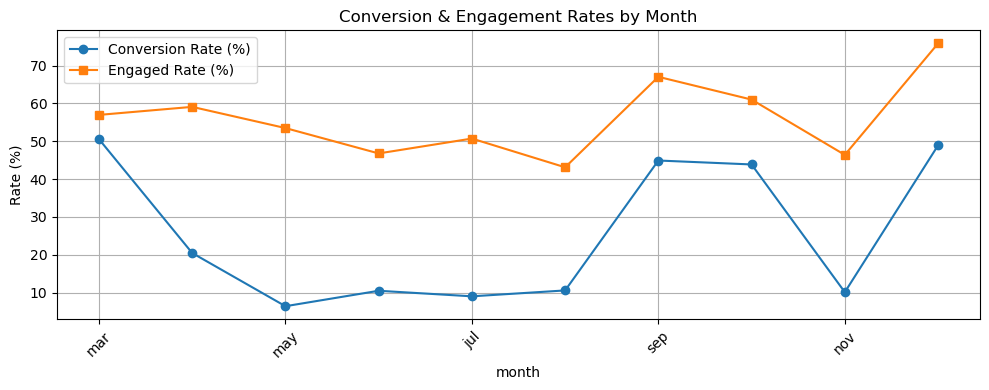

In [23]:
# Ensure month order
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

monthly_conv = df.groupby('month', observed=False)['converted'].mean() * 100
monthly_engaged = df.groupby('month', observed=False)['engaged'].mean() * 100

plt.figure(figsize=(10,4))
monthly_conv.plot(kind='line', marker='o', label='Conversion Rate (%)')
monthly_engaged.plot(kind='line', marker='s', label='Engaged Rate (%)')
plt.title('Conversion & Engagement Rates by Month')
plt.ylabel('Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

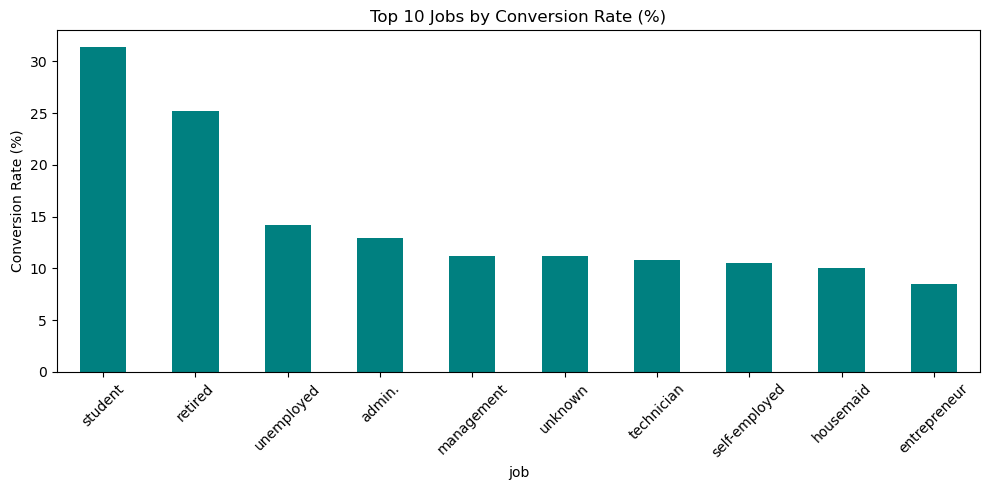

In [24]:
# Top 5 jobs by conversion rate
job_conv = df.groupby('job')['converted'].mean() * 100
job_conv_sorted = job_conv.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
job_conv_sorted.plot(kind='bar', color='teal')
plt.title('Top 10 Jobs by Conversion Rate (%)')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Select relevant columns for dashboard
export_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
               'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
               'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
               'euribor3m', 'nr.employed', 'converted', 'engaged']

df_export = df[export_cols].copy()
df_export.to_csv('cleaned_marketing_funnel.csv', index=False)

print("\nCleaned data saved as 'cleaned_marketing_funnel.csv'")
print("Shape:", df_export.shape)


Cleaned data saved as 'cleaned_marketing_funnel.csv'
Shape: (41188, 22)
